<a href="https://colab.research.google.com/github/rimsharish/Titanic---Machine-Learning-from-Disaster/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports
Load the core libraries we'll need: **NumPy** for numerical operations and **Pandas** for working with tabular data.

In [ ]:
import numpy as np
import pandas as pd

## Load the dataset
Read the Titanic training data from `train.csv` into a DataFrame and preview the first few rows.

In [ ]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Structure overview
Use `.info()` to check column data types, the number of entries, and which columns have missing values.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Summary statistics
Use `.describe()` to see count, mean, std, min/max, and quartiles for the numeric columns.

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Check for missing values
Print a boolean mask showing exactly which cells are null across the DataFrame.

In [ ]:
print(df.isnull())

     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   

      Fare  Cabin  Embarked

## Fill missing Age values
Age has missing values, so fill them with the column mean as a simple imputation strategy.

In [ ]:
filled_age = df['Age'].fillna(df['Age'].mean())
print(f"filled age = {filled_age}")

filled age = 0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64


## Fill missing Embarked values
Embarked also has a few missing values; fill them with the most frequent value (mode).

In [ ]:
print(df['Embarked'].fillna(df['Embarked'].mode()))

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object


## Survival rate by sex
Group by `Sex` and compute the mean of `Survived` (since Survived is 0/1, the mean is the survival rate).

In [ ]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


## Survival rate by sex (detailed)
Break the calculation down explicitly: total survivors, total passengers, then the resulting rate per sex, as a percentage.

In [ ]:
total_survivors = df.groupby('Sex')['Survived'].sum()
total_passengers = df.groupby('Sex')['Survived'].count()
print(total_survivors)
print(total_passengers)
survival_rate_by_sex = (total_survivors/total_passengers)*100
print(f"survival_rate_by_sex = {survival_rate_by_sex}")

Sex
female    233
male      109
Name: Survived, dtype: int64
Sex
female    314
male      577
Name: Survived, dtype: int64
survival_rate_by_sex = Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


## Survival rate by passenger class
Repeat the same survivor-count / passenger-count / rate breakdown, this time grouped by `Pclass`.

In [ ]:
total_survivors = df.groupby('Pclass')['Survived'].sum()
total_passengers = df.groupby('Pclass')['Survived'].count()
print(total_survivors)
print(total_passengers)
survival_rate_by_pclass = (total_survivors/total_passengers)*100
print(f"survival rate by pclass = {survival_rate_by_pclass}")

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64
Pclass
1    216
2    184
3    491
Name: Survived, dtype: int64
survival rate by pclass = Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


## Survival rate by embarkation port
Same approach again, grouped by `Embarked` (port of embarkation).

In [ ]:
total_survivors = df.groupby('Embarked')['Survived'].sum()
total_passengers = df.groupby('Embarked')['Survived'].count()
print(total_survivors)
print(total_passengers)
print((total_survivors/total_passengers)*100)

Embarked
C     93
Q     30
S    217
Name: Survived, dtype: int64
Embarked
C    168
Q     77
S    644
Name: Survived, dtype: int64
Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


## Average age by survival outcome
Compare the mean `Age` of passengers who survived vs. those who didn't.

In [ ]:
df.groupby('Survived')['Age'].mean()

,Age
Survived,
0,30.626179
1,28.343690


## Define an age categorization function
Create a helper function that buckets a passenger's age into `Child`, `Adult`, or `Senior`.

In [ ]:
def categorize_age(Age):
  if Age <= 10:
    return 'Child'
  elif Age <= 30:
    return 'Adult'
  else:
    return 'Senior'

## Apply age categorization
Use `.apply()` to create a new `AgeGroup` column based on the function above.

In [ ]:
df['AgeGroup'] = df['Age'].apply(categorize_age)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Senior
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Senior
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Adult
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Adult
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Senior
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Adult


## Import plotting library
Bring in `matplotlib.pyplot` for visualizations.

In [ ]:
import matplotlib.pyplot as plt

## Bar chart: survival rate by gender (manual values)
A quick bar chart using hardcoded survival-rate values for male vs. female.

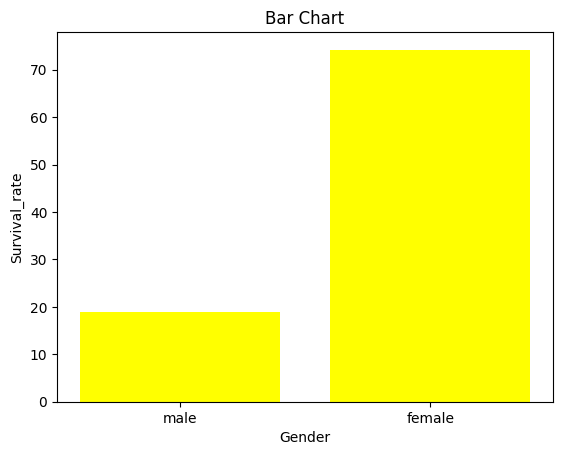

In [ ]:
Gender = ['male','female']
Survival_rate = [18.9,74.2]

plt.bar(Gender, Survival_rate, color='yellow')
plt.title("Bar Chart")
plt.xlabel("Gender")
plt.ylabel("Survival_rate")
plt.show()



## Bar chart: survival rate by gender (computed values)
Same idea, but plotted directly from the `survival_rate_by_sex` Series calculated earlier.

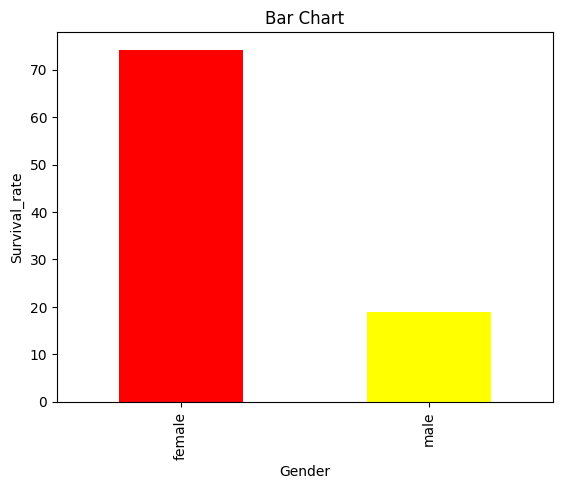

In [ ]:
colors = ['red','yellow']
survival_rate_by_sex.plot(kind='bar',color = colors)
plt.title("Bar Chart")
plt.xlabel("Gender")
plt.ylabel("Survival_rate")
plt.show()

## Bar chart: survival rate by passenger class
Visualize the survival rate across the three passenger classes.

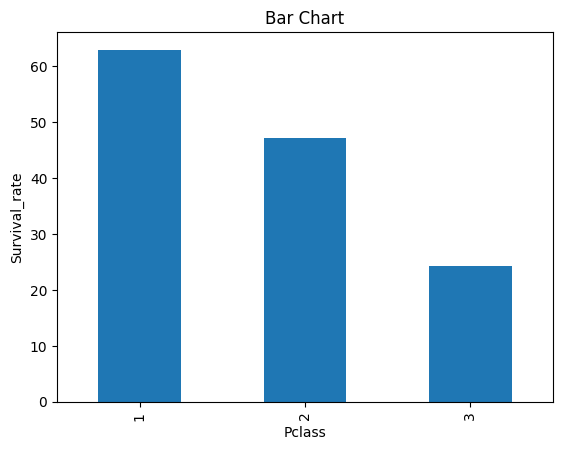

In [ ]:
survival_rate_by_pclass.plot(kind='bar')
plt.title("Bar Chart")
plt.xlabel("Pclass")
plt.ylabel("Survival_rate")
plt.show()

## Histogram: age distribution
Plot the distribution of (mean-imputed) passenger ages.

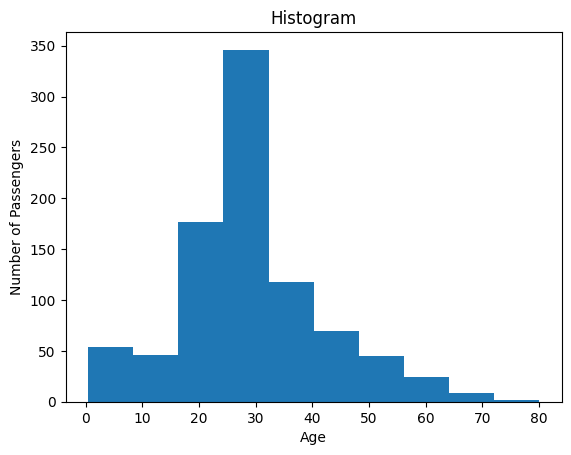

In [ ]:
filled_age.plot(kind='hist')
plt.title("Histogram")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

## Pie chart: class distribution
Show the proportion of passengers in each passenger class.

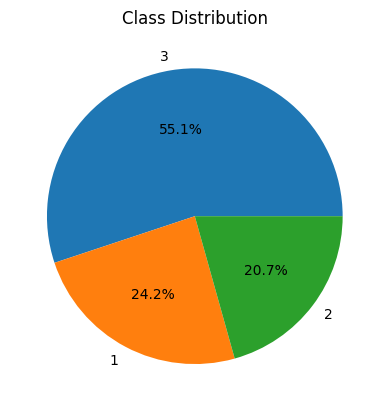

In [ ]:
class_distribution = df['Pclass'].value_counts()
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()